# ITEC623 – Deep Learning and Emerging Topics in Artificial Intelligence

## Lab 1: Development Environment, Hardware Acceleration & Dataset Inspection

**Student Name:** Emmanuel Orunta


**Student ID:** S00403657

---

## Task 1 – Environment Setup and Verification

In [2]:
## Loading Libraries

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

print("\nAvailable devices:")
print(tf.config.list_physical_devices())

print("\nAvailable GPUs:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
Keras version: 3.13.2

Available devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Available GPUs:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Cloud notebooks are useful for deep-learning work because they provide access to computing resources without requiring a powerful local computer. Google Colab also makes it easy to install and use libraries such as TensorFlow and Keras.

## TASK 2 — GPU, Matrix Operations and Performance

In [3]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Random seeds have been set.")

Random seeds have been set.


In [4]:
# Matrix size
matrix_size = 3000

# Generate two random matrices using a normal distribution
matrix_a = tf.random.normal(
    shape=(matrix_size, matrix_size),
    mean=0.0,
    stddev=1.0,
    dtype=tf.float32
)

matrix_b = tf.random.normal(
    shape=(matrix_size, matrix_size),
    mean=0.0,
    stddev=1.0,
    dtype=tf.float32
)

print("Matrix A shape:", matrix_a.shape)
print("Matrix B shape:", matrix_b.shape)

Matrix A shape: (3000, 3000)
Matrix B shape: (3000, 3000)


In [5]:
import time

# CPU multiplication
with tf.device('/CPU:0'):
    start_time = time.perf_counter()

    result_cpu = tf.matmul(matrix_a, matrix_b)

    # Force TensorFlow to finish the calculation
    result_cpu.numpy()

    cpu_time = time.perf_counter() - start_time

print(f"CPU execution time: {cpu_time:.6f} seconds")

CPU execution time: 0.637497 seconds


In [6]:
## GPU matrix multiplication

gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    with tf.device('/GPU:0'):
        start_time = time.perf_counter()

        result_gpu = tf.matmul(matrix_a, matrix_b)

        # Force TensorFlow to finish the calculation
        result_gpu.numpy()

        gpu_time = time.perf_counter() - start_time

    print(f"GPU execution time: {gpu_time:.6f} seconds")
else:
    print("No GPU is available.")

GPU execution time: 0.158332 seconds


In [7]:
## Comparing of results

if gpu_devices:
    print("CPU time:", cpu_time, "seconds")
    print("GPU time:", gpu_time, "seconds")

    speedup = cpu_time / gpu_time

    print(f"GPU speedup: {speedup:.2f}x")
else:
    print("GPU comparison cannot be performed because no GPU is available.")

CPU time: 0.637497269999983 seconds
GPU time: 0.1583318969999823 seconds
GPU speedup: 4.03x


In [8]:
def benchmark_matmul(device, matrix_a, matrix_b, repetitions=5):
    times = []

    # Warm-up run
    with tf.device(device):
        warmup = tf.matmul(matrix_a, matrix_b)
        warmup.numpy()

    # Timed runs
    for _ in range(repetitions):
        with tf.device(device):
            start = time.perf_counter()

            result = tf.matmul(matrix_a, matrix_b)

            # Ensure operation has completed
            result.numpy()

            elapsed = time.perf_counter() - start
            times.append(elapsed)

    return np.mean(times), np.std(times)


cpu_mean, cpu_std = benchmark_matmul(
    '/CPU:0',
    matrix_a,
    matrix_b
)

print(f"CPU mean time: {cpu_mean:.6f} seconds")
print(f"CPU standard deviation: {cpu_std:.6f} seconds")


if gpu_devices:
    gpu_mean, gpu_std = benchmark_matmul(
        '/GPU:0',
        matrix_a,
        matrix_b
    )

    print(f"GPU mean time: {gpu_mean:.6f} seconds")
    print(f"GPU standard deviation: {gpu_std:.6f} seconds")

    print(f"GPU speedup: {cpu_mean / gpu_mean:.2f}x")

CPU mean time: 0.583614 seconds
CPU standard deviation: 0.091555 seconds
GPU mean time: 0.061093 seconds
GPU standard deviation: 0.001534 seconds
GPU speedup: 9.55x


Matrix operations are central to deep learning because neural networks repeatedly perform operations such as matrix multiplication when processing inputs and applying learned weights. I compared the execution time of the same matrix multiplication on the CPU and GPU to see how the two types of hardware handle the workload. The GPU is designed to perform many numerical operations in parallel, which can make it more suitable for large deep-learning computations. Randomly generated matrices are useful for benchmarking because they provide a controlled workload without depending on a particular dataset. The actual timing also shows why hardware choice can affect model training performance. In my experiment, the GPU completed the operation faster than the CPU.

## TASK 3 — Hardware Concepts Reflection

*  What is a CPU?
*  What is a GPU?
*  Why GPUs accelerate deep-learning training?


A CPU is a general-purpose processor designed to handle many different types of computing tasks. A GPU is a processor that contains many smaller processing units and is designed to perform large numbers of operations in parallel.
GPUs fasten deep-learning training because they use thousands of small cores to run many math operations at the same time. While a standard CPU handles a few complex tasks one after another, a GPU processes huge grids of numbers like the massive matrix multiplications in neural networks all in parallel
In Task 2, I compared matrix multiplication using the CPU and GPU and observed a difference in execution time. The result helped me understand why GPUs are commonly used for neural network training, especially when the workload contains many operations that can be processed simultaneously.

## TASK 4 — Classical Dataset Inspection (Iris)

In [9]:
## Load Iris dataset

from sklearn.datasets import load_iris

iris = load_iris()

X_iris = iris.data
y_iris = iris.target

print("Dataset shape:", X_iris.shape)
print("Feature names:", iris.feature_names)
print("Class names:", iris.target_names)
print("Class labels:", np.unique(y_iris))

Dataset shape: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa' 'versicolor' 'virginica']
Class labels: [0 1 2]


In [15]:
## DataFrame Creation

iris_df = pd.DataFrame(
    X_iris,
    columns=iris.feature_names
)

iris_df["target"] = y_iris

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [16]:
## Basic statistics
iris_df.describe()

## Class distribution
print("Class distribution:")
print(pd.Series(y_iris).value_counts().sort_index())

Class distribution:
0    50
1    50
2    50
Name: count, dtype: int64


The Iris dataset contains 150 observations with four numerical features describing the sepal and petal measurements of three different iris species. Each observation belongs to one of three classes. The dataset is relatively small and contains structured numerical features, which makes it suitable for testing and understanding simple machine-learning models. It is also useful for classification because the features provide information that can help distinguish between the different classes. Compared with image datasets, Iris requires much less computational processing and does not normally require a complex neural network.

## Task 5 — Deep-Learning Dataset Inspection (MNIST and CIFAR-10)

In [12]:
## MNIST

from tensorflow.keras.datasets import mnist

(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

print("MNIST training images:", X_train_mnist.shape)
print("MNIST training labels:", y_train_mnist.shape)

print("MNIST test images:", X_test_mnist.shape)
print("MNIST test labels:", y_test_mnist.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MNIST training images: (60000, 28, 28)
MNIST training labels: (60000,)
MNIST test images: (10000, 28, 28)
MNIST test labels: (10000,)


In [13]:
## MNIST class names

mnist_class_names = [
    "0", "1", "2", "3", "4",
    "5", "6", "7", "8", "9"
]

print("MNIST classes:")
print(mnist_class_names)

MNIST classes:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


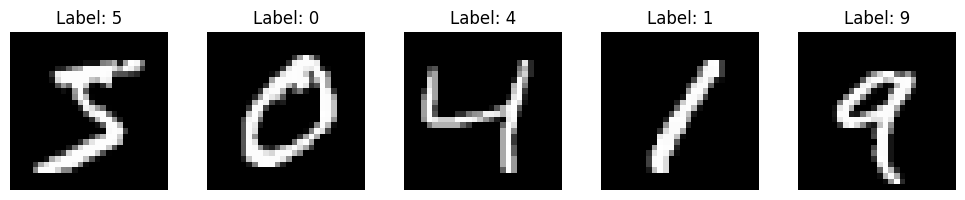

In [14]:
## Display five MNIST images

plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train_mnist[i], cmap="gray")
    plt.title(f"Label: {y_train_mnist[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# CIFAR

from tensorflow.keras.datasets import cifar10

(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

print("CIFAR-10 training images:", X_train_cifar.shape)
print("CIFAR-10 training labels:", y_train_cifar.shape)

print("CIFAR-10 test images:", X_test_cifar.shape)
print("CIFAR-10 test labels:", y_test_cifar.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2563s 15us/step
CIFAR-10 training images: (50000, 32, 32, 3)
CIFAR-10 training labels: (50000, 1)
CIFAR-10 test images: (10000, 32, 32, 3)
CIFAR-10 test labels: (10000, 1)


In [18]:
## CIFAR-10 class names

cifar_class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("CIFAR-10 classes:")
for i, name in enumerate(cifar_class_names):
    print(i, ":", name)

CIFAR-10 classes:
0 : airplane
1 : automobile
2 : bird
3 : cat
4 : deer
5 : dog
6 : frog
7 : horse
8 : ship
9 : truck


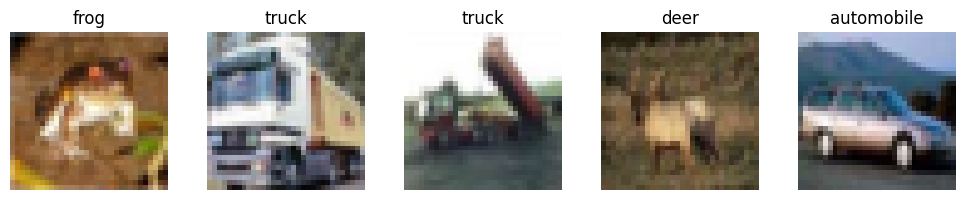

In [19]:
## Display five CIFAR-10 images

plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train_cifar[i])
    plt.title(cifar_class_names[y_train_cifar[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Iris contains only four numerical features for each observation, so its data structure is relatively simple and can be handled by traditional machine-learning algorithms. MNIST and CIFAR-10 are more complex because the input is represented as images. MNIST contains 28 × 28 grayscale images, while CIFAR-10 contains 32 × 32 colour images with three channels. Image data contains many more input values and spatial information, so models such as convolutional neural networks are more appropriate for learning useful patterns from these datasets.

## TASK 6 — Reproducibility and Responsible Practice

In [20]:
# Set seed for reproducibility
np.random.seed(42)

# Create time values
time_values = np.linspace(0, 10, 500)

# Create a sine wave
signal = np.sin(time_values)

# Generate Gaussian noise
noise = np.random.normal(
    loc=0,
    scale=0.2,
    size=len(time_values)
)

# Add noise to the signal
noisy_signal = signal + noise

print("Number of observations:", len(noisy_signal))
print("First five values:", noisy_signal[:5])

Number of observations: 500
First five values: [ 0.09934283 -0.00761412  0.16960714  0.36469     0.03324383]


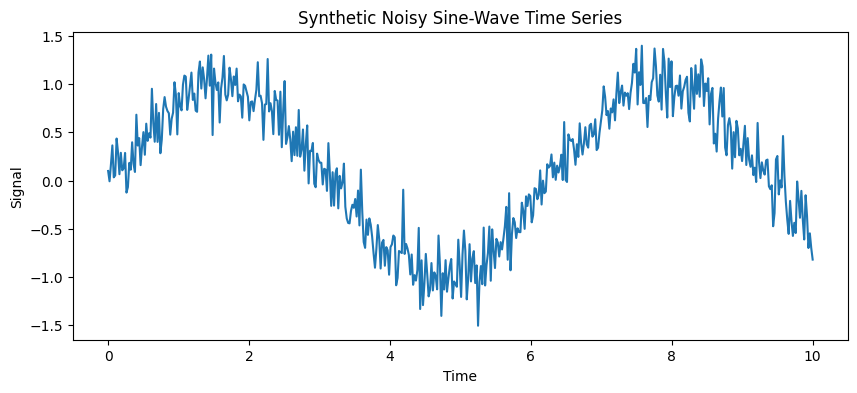

In [21]:
## Plot the synthetic time series

plt.figure(figsize=(10, 4))

plt.plot(time_values, noisy_signal)

plt.xlabel("Time")
plt.ylabel("Signal")
plt.title("Synthetic Noisy Sine-Wave Time Series")

plt.show()

Setting a random seed helps make experiments reproducible because the same pseudo-random sequence can be generated again. Python and NumPy use pseudo-random number generators, meaning that the numbers appear random but are produced using a deterministic algorithm. Synthetic data can be useful for testing models before applying them to real datasets. For example, a noisy sine wave can represent a simple time-series signal for testing forecasting or anomaly detection. However, synthetic data should not automatically be treated as equivalent to real-world data. Ethical issues such as privacy, bias and misleading conclusions should still be considered when using or presenting synthetic data.